<a href="https://colab.research.google.com/github/ramandeepp1403/Covid-Trends/blob/main/covidtrends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Covid  Analyzing the trends
Problem Statement:
Given data about COVID-19 patients, write code to visualize the impact and
analyze the trend of rate of infection and recovery as well as make predictions
about the number of cases expected a week in future based on the current
trends.

Guidelines:
 ● Usepandas to accumulate data from multiple data files.
 ● Useplotly (visualization library) to create interactive visualizations.
 ● UseFacebook prophet library to make time series models.
 ● Visualize the prediction by combining these technologies.



In [ ]:
!pip install --quiet prophet plotly==5.11.0 chart-studio

In [ ]:
import pandas as pd
import numpy as np
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_
import matplotlib.pyplot as plt
import plotly.express as px
from prophet import Prophet
from datetime import timedelta

In [ ]:
df= pd.read_csv('/content/covid_19_clean_complete.csv')

In [ ]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [ ]:
df.drop('Province/State',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country/Region  49068 non-null  object 
 1   Lat             49068 non-null  float64
 2   Long            49068 non-null  float64
 3   Date            49068 non-null  object 
 4   Confirmed       49068 non-null  int64  
 5   Deaths          49068 non-null  int64  
 6   Recovered       49068 non-null  int64  
 7   Active          49068 non-null  int64  
 8   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 3.4+ MB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
grpby_country= df.groupby('Country/Region')[['Confirmed','Deaths','Recovered','Active']].sum()

In [ ]:
grpby_country

,Confirmed,Deaths,Recovered,Active
Country/Region,,,,
Afghanistan,1936390,49098,798240,1089052
Albania,196702,5708,118877,72117
Algeria,1179755,77972,755897,345886
Andorra,94404,5423,69074,19907
Angola,22662,1078,6573,15011
...,...,...,...,...
West Bank and Gaza,233461,1370,61124,170967
Western Sahara,901,63,648,190
Yemen,67180,17707,23779,25694


In [ ]:
df.columns = [c.strip() for c in df.columns] #help in removing any space from col names
df["Date"] = pd.to_datetime(df["Date"])

#Compututing here Active cases if missing
if "Active" not in df.columns or df["Active"].isna().any():
    df["Active"] = df["Confirmed"] - df["Deaths"] - df["Recovered"]#Active = Confirmed - Deaths - Recovered

In [ ]:
#sorting vlaues now:
df = df.sort_values(["Country/Region","Date"])
print("Data ready!")

Data ready!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49068 entries, 0 to 49035
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.7+ MB


In [ ]:
#worldwide data
world = df.groupby("Date", as_index=False)[["Confirmed","Deaths","Recovered","Active"]].sum()
world["Daily New Cases"] = world["Confirmed"].diff().fillna(0)
world["Recovery Rate (%)"] = (world["Recovered"] / world["Confirmed"]).replace([float('inf'), float('nan')], 0) * 100
world["Death Rate (%)"] = (world["Deaths"] / world["Confirmed"]).replace([float('inf'), float('nan')], 0) * 100

world.tail()


,Date,Confirmed,Deaths,Recovered,Active,Daily New Cases,Recovery Rate (%),Death Rate (%)
183,2020-07-23,15510481,633506,8710969,6166006,282756.0,56.161824,4.084374
184,2020-07-24,15791645,639650,8939705,6212290,281164.0,56.610347,4.050560
185,2020-07-25,16047190,644517,9158743,6243930,255545.0,57.073812,4.016385
186,2020-07-26,16251796,648621,9293464,6309711,204606.0,57.184228,3.991073
187,2020-07-27,16480485,654036,9468087,6358362,228689.0,57.450293,3.968548


In [ ]:
#plotly part

fig1 = px.line(world, x="Date", y=["Confirmed","Recovered","Deaths"],
               title="🌍 Global COVID-19 Cumulative Cases",
               labels={"value":"Number of Cases","variable":"Category"})
fig1.show()


fig2 = px.line(world, x="Date", y="Daily New Cases",
               title="📈 Daily New COVID-19 Cases Worldwide")
fig2.show()


fig3 = px.line(world, x="Date", y=["Recovery Rate (%)","Death Rate (%)"],
               title="⚖️ Recovery vs Death Rate (%)")
fig3.show()


/usr/local/lib/python3.12/dist-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



/usr/local/lib/python3.12/dist-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



/usr/local/lib/python3.12/dist-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpp6gh0fur/if5p5z0y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpp6gh0fur/8bmzpzrs.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5851', 'data', 'file=/tmp/tmpp6gh0fur/if5p5z0y.json', 'init=/tmp/tmpp6gh0fur/8bmzpzrs.json', 'output', 'file=/tmp/tmpp6gh0fur/prophet_model58_m4uff/prophet_model-20251018182915.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


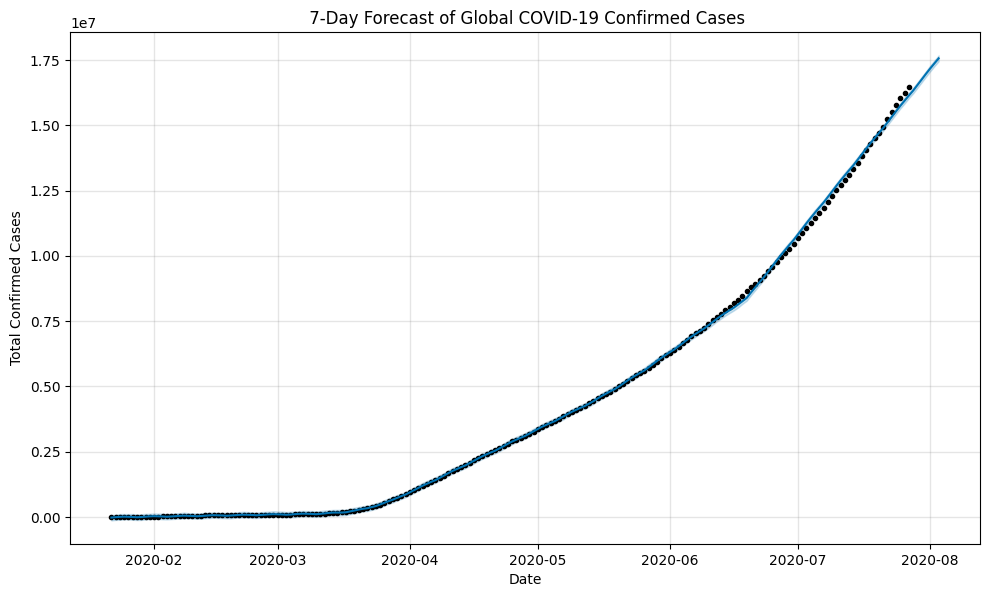

,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,1.632170e+07,1.621456e+07,1.642413e+07
189,2020-07-29,1.653160e+07,1.642573e+07,1.663954e+07
190,2020-07-30,1.674571e+07,1.663812e+07,1.685006e+07
191,2020-07-31,1.696092e+07,1.684886e+07,1.706343e+07
192,2020-08-01,1.716865e+07,1.705984e+07,1.728142e+07
193,2020-08-02,1.736627e+07,1.725729e+07,1.748205e+07
194,2020-08-03,1.756093e+07,1.744683e+07,1.767328e+07


In [ ]:
#forecasting
forecast_df = world[["Date","Confirmed"]].rename(columns={"Date":"ds","Confirmed":"y"})

model = Prophet(daily_seasonality=True)
model.fit(forecast_df)

future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title(" 7-Day Forecast of Global COVID-19 Confirmed Cases")
plt.xlabel("Date"); plt.ylabel("Total Confirmed Cases")
plt.show()

forecast.tail(7)[["ds","yhat","yhat_lower","yhat_upper"]]


In [ ]:
india = df[df["Country/Region"]=="India"].groupby("Date",as_index=False)[["Confirmed","Recovered","Deaths"]].sum()
fig = px.line(india, x="Date", y=["Confirmed","Recovered","Deaths"],
              title="🇮🇳 India COVID-19 Trends")
fig.show()


/usr/local/lib/python3.12/dist-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [ ]:
last = int(world["Confirmed"].iloc[-1])
pred = int(forecast["yhat"].iloc[-1])
print(f"🦠 Current global confirmed: {last:,}")
print(f"📅 Predicted after 7 days: {pred:,}")
print(f"📈 Expected increase: {pred - last:,} cases")


🦠 Current global confirmed: 16,480,485
📅 Predicted after 7 days: 17,560,929
📈 Expected increase: 1,080,444 cases
